# PhonePe Transaction & Demographic Analysis
### Python Data Analyst Case Study

**Objective:** Analyze transaction trends, user behavior, device usage and demographic relationships across Indian states and districts using Pandas, NumPy, Matplotlib and Seaborn.

This notebook covers Tasks 1–6 from the provided case study and uses the supplied PhonePe Excel workbook.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

DATA_FILE = Path('phonepe_data.xlsx')


## 1. Data Loading and Understanding

In [2]:
# Load all required sheets
state_txn = pd.read_excel(DATA_FILE, sheet_name='State_Txn and Users')
state_split = pd.read_excel(DATA_FILE, sheet_name='State_TxnSplit')
state_device = pd.read_excel(DATA_FILE, sheet_name='State_DeviceData')
district_txn = pd.read_excel(DATA_FILE, sheet_name='District_Txn and Users')
district_demo = pd.read_excel(DATA_FILE, sheet_name='District Demographics')

for df in [state_txn, state_split, state_device, district_txn, district_demo]:
    df.columns = df.columns.str.strip()

print("Sheets loaded successfully.")


Sheets loaded successfully.


In [3]:
# 1.1 Required row displays
display(state_txn.head(5))
display(state_split.tail(10))

mid = len(state_device) // 2
display(state_device.iloc[max(0, mid-5):mid+5])

display(district_txn.head(10))
display(district_txn.tail(10))

display(district_demo.iloc[::10])


,State,Year,Quarter,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,6658,"14,631,761.22","2,197.62",6740,0
1,Andaman & Nicobar Islands,2018,2,11340,"28,338,535.51","2,498.99",9405,0
2,Andaman & Nicobar Islands,2018,3,16265,"55,557,471.13","3,415.77",12149,0
3,Andaman & Nicobar Islands,2018,4,23758,"90,548,336.07","3,811.28",15222,0
4,Andaman & Nicobar Islands,2019,1,30486,"102,299,740.67","3,355.63",18596,0


,State,Year,Quarter,Transaction Type,Transactions,Amount (INR),ATV (INR)
2504,West Bengal,2021,1,Peer-to-peer payments,53869075,"202,240,249,482.85","3,754.29"
2505,West Bengal,2021,1,Merchant payments,37143701,"28,918,343,691.02",778.55
2506,West Bengal,2021,1,Recharge & bill payments,26673733,"11,339,665,944.69",425.12
2507,West Bengal,2021,1,Financial Services,166727,"175,445,811.88","1,052.29"
2508,West Bengal,2021,1,Others,400816,"263,502,545.07",657.42
2509,West Bengal,2021,2,Peer-to-peer payments,64661051,"230,812,278,789.30","3,569.57"
2510,West Bengal,2021,2,Merchant payments,41696787,"34,787,867,208.32",834.31
2511,West Bengal,2021,2,Recharge & bill payments,34799709,"13,331,453,857.61",383.09
2512,West Bengal,2021,2,Financial Services,190537,"186,466,487.63",978.64
2513,West Bengal,2021,2,Others,549353,"316,744,715.70",576.58


,State,Year,Quarter,Brand,Registered Users,Percentage
2767,Ladakh,2021,2,OnePlus,1741,0.02
2768,Ladakh,2021,2,Motorola,922,0.01
2769,Ladakh,2021,2,Huawei,894,0.01
2770,Ladakh,2021,2,Lenovo,490,0.01
2771,Ladakh,2021,2,Others,2610,0.03
2772,Lakshadweep,2018,1,Samsung,102,0.20
2773,Lakshadweep,2018,1,Xiaomi,100,0.20
2774,Lakshadweep,2018,1,Vivo,67,0.13
2775,Lakshadweep,2018,1,Oppo,56,0.11
2776,Lakshadweep,2018,1,Huawei,25,0.05


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
0,Andaman & Nicobar Islands,2018,1,Nicobars,AN01,528,"1,139,848.80","2,158.80",262,0
1,Andaman & Nicobar Islands,2018,1,North And Middle Andaman,AN02,442,"931,663.08","2,107.84",632,0
2,Andaman & Nicobar Islands,2018,1,South Andaman,AN03,5688,"12,560,249.34","2,208.20",5846,0
3,Andaman & Nicobar Islands,2018,2,Nicobars,AN01,1120,"3,072,436.91","2,743.25",351,0
4,Andaman & Nicobar Islands,2018,2,North And Middle Andaman,AN02,825,"1,317,863.08","1,597.41",911,0
5,Andaman & Nicobar Islands,2018,2,South Andaman,AN03,9395,"23,948,235.52","2,549.04",8143,0
6,Andaman & Nicobar Islands,2018,3,Nicobars,AN01,1471,"6,387,829.15","4,342.51",467,0
7,Andaman & Nicobar Islands,2018,3,North And Middle Andaman,AN02,1283,"4,901,529.52","3,820.37",1208,0
8,Andaman & Nicobar Islands,2018,3,South Andaman,AN03,13511,"44,268,112.46","3,276.45",10474,0
9,Andaman & Nicobar Islands,2018,4,Nicobars,AN01,1485,"7,180,859.35","4,835.60",536,0


,State,Year,Quarter,District,Code,Transactions,Amount (INR),ATV (INR),Registered Users,App Opens
10238,West Bengal,2021,2,Murshidabad,WB14,8602251,"19,996,935,608.24","2,324.62",1248602,16530655
10239,West Bengal,2021,2,Nadia,WB15,5524174,"11,227,582,723.38","2,032.45",955428,13665885
10240,West Bengal,2021,2,North Twenty Four Parganas,WB16,17258291,"30,414,821,772.93","1,762.33",2660664,37899453
10241,West Bengal,2021,2,Paschim Bardhaman,WB17,4893774,"8,731,262,893.73","1,784.16",789026,10545670
10242,West Bengal,2021,2,Paschim Medinipur,WB18,5051834,"10,303,513,378.80","2,039.56",856640,16201033
10243,West Bengal,2021,2,Purba Bardhaman,WB19,3920729,"7,572,502,416.24","1,931.40",787970,12128849
10244,West Bengal,2021,2,Purba Medinipur,WB20,6418522,"15,155,067,721.27","2,361.15",946277,15491958
10245,West Bengal,2021,2,Purulia,WB21,1895981,"2,790,996,372.04","1,472.06",435131,8843358
10246,West Bengal,2021,2,South Twenty Four Parganas,WB22,6661813,"13,398,529,483.67","2,011.24",1286588,19344293
10247,West Bengal,2021,2,Uttar Dinajpur,WB23,2253385,"5,564,220,751.05","2,469.27",392388,8184990


,State,District,Headquarters,Population,Area (sq km),Density,Code,Alternate Name
0,Andhra Pradesh,Anantapur,Anantapur,4083315,"19,130.00",213,AP01,Anantapur
10,Andhra Pradesh,Visakhapatnam,Visakhapatnam,4288113,"11,161.00",384,AP10,Visakhapatnam
20,Arunachal Pradesh,Lepa Rada,Basar,0,0.00,0,AR08,Lepa Rada
30,Arunachal Pradesh,Siang,Pangin,31920,"2,919.00",11,AR18,Siang
40,Assam,Barpeta,Barpeta,1693622,"3,245.00",520,AS03,Barpeta
...,...,...,...,...,...,...,...,...
700,Chandigarh,Chandigarh,Chandigarh,1055450,114.00,9258,CH01,Chandigarh
710,Jammu & Kashmir,Jammu,Jammu,1526406,"3,097.00",596,JK07,Jammu
720,Jammu & Kashmir,Samba,Samba,318611,913.00,318,JK17,Samba
730,Delhi,North Delhi,Sadar Bazaar,887978,59.00,14557,DL04,North


In [4]:
# 1.2 Summary statistics and data types
for name, df in {
    'State_Txn and Users': state_txn,
    'State_TxnSplit': state_split,
    'State_DeviceData': state_device,
    'District_Txn and Users': district_txn,
    'District Demographics': district_demo
}.items():
    print(f'\n===== {name} =====')
    display(df.describe(include='number').T)
    print('Data types:')
    display(df.dtypes.to_frame('dtype'))



===== State_Txn and Users =====


,count,mean,std,min,25%,50%,75%,max
Year,504.00,"2,019.29",1.03,"2,018.00","2,018.00","2,019.00","2,020.00","2,021.00"
Quarter,504.00,2.36,1.11,1.00,1.00,2.00,3.00,4.00
Transactions,504.00,"40,740,000.58","82,287,143.49",778.00,"592,557.75","6,217,487.00","43,636,745.50","573,616,486.00"
Amount (INR),503.00,"70,833,320,601.59","144,090,233,156.01","1,928,611.18","1,167,157,028.93","10,516,054,014.09","69,470,450,912.08","1,027,958,332,797.58"
ATV (INR),504.00,"1,993.47",607.46,0.00,"1,598.91","1,861.38","2,259.09","3,938.73"
Registered Users,504.00,"4,777,500.89","6,644,495.72",501.00,"157,420.25","1,747,914.00","7,320,945.25","39,664,697.00"
App Opens,504.00,"97,744,705.23","204,237,579.80",0.00,0.00,"2,930,573.50","86,150,218.25","1,208,083,592.00"


Data types:


,dtype
State,object
Year,int64
Quarter,int64
Transactions,int64
Amount (INR),float64
ATV (INR),float64
Registered Users,int64
App Opens,int64



===== State_TxnSplit =====


...

,dtype
State,object
Year,int64
Quarter,int64
District,object
Code,object
Transactions,int64
Amount (INR),float64
ATV (INR),float64
Registered Users,int64
App Opens,int64



===== District Demographics =====


,count,mean,std,min,25%,50%,75%,max
Population,742.00,"1,668,554.61","1,458,849.18",0.00,"653,081.50","1,322,359.00","2,297,440.00","10,082,852.00"
Area (sq km),742.00,"4,395.37","4,254.68",0.00,"2,039.75","3,402.50","5,432.75","45,652.00"
Density,742.00,838.51,"2,754.41",0.00,198.00,353.00,686.25,"36,155.00"


Data types:


,dtype
State,object
District,object
Headquarters,object
Population,int64
Area (sq km),float64
Density,int64
Code,object
Alternate Name,object


In [5]:
# 1.3 Missing-value analysis
for name, df in {
    'State_Txn and Users': state_txn,
    'State_TxnSplit': state_split,
    'State_DeviceData': state_device,
    'District_Txn and Users': district_txn,
    'District Demographics': district_demo
}.items():
    missing_pct = (df.isna().mean() * 100).sort_values(ascending=False)
    missing_pct = missing_pct[missing_pct > 0]
    print(f'\n===== {name} =====')
    if missing_pct.empty:
        print('No missing values found.')
    else:
        display(missing_pct.to_frame('missing_percentage'))
        print('Highest missing column:', missing_pct.idxmax(), f'({missing_pct.max():.2f}%)')



===== State_Txn and Users =====


,missing_percentage
Amount (INR),0.20


Highest missing column: Amount (INR) (0.20%)

===== State_TxnSplit =====
No missing values found.

===== State_DeviceData =====
No missing values found.

===== District_Txn and Users =====


,missing_percentage
Code,0.27
ATV (INR),0.04


Highest missing column: Code (0.27%)

===== District Demographics =====
No missing values found.


In [6]:
# 1.4 States, districts and state with most districts
total_states = state_txn['State'].nunique()
total_districts = district_demo['District'].nunique()

district_count = district_demo.groupby('State')['District'].nunique().sort_values(ascending=False)

print('Total states:', total_states)
print('Total districts:', total_districts)
print('State with highest number of districts:', district_count.idxmax())
print('Number of districts:', district_count.max())


Total states: 36
Total districts: 736
State with highest number of districts: Uttar Pradesh
Number of districts: 75


## 2. Exploratory Data Analysis

In [7]:
# 2.1 Transaction trends by state and year
state_year_txn = state_txn.groupby(['State','Year'], as_index=False)['Transactions'].sum()
display(state_year_txn)

top5_states = state_txn.groupby('State')['Transactions'].sum().nlargest(5)
bottom5_states = state_txn.groupby('State')['Transactions'].sum().nsmallest(5)

print('Top 5 states by transaction volume')
display(top5_states.to_frame('Transactions'))

print('Bottom 5 states by transaction volume')
display(bottom5_states.to_frame('Transactions'))


,State,Year,Transactions
0,Andaman & Nicobar Islands,2018,58021
1,Andaman & Nicobar Islands,2019,133104
2,Andaman & Nicobar Islands,2020,446274
3,Andaman & Nicobar Islands,2021,586166
4,Andhra Pradesh,2018,77779112
...,...,...,...
139,Uttarakhand,2021,44608834
140,West Bengal,2018,120011635
141,West Bengal,2019,257900590
142,West Bengal,2020,304222327


Top 5 states by transaction volume


,Transactions
State,
Karnataka,2981044533
Maharashtra,2833670154
Telangana,2347430243
Andhra Pradesh,1781091169
Rajasthan,1382918930


Bottom 5 states by transaction volume


,Transactions
State,
Lakshadweep,71610
Andaman & Nicobar Islands,1223565
Ladakh,1880109
Mizoram,2162776
Meghalaya,5648913


In [8]:
# 2.2 Most frequent transaction type for each state and quarter
idx = state_split.groupby(['State','Year','Quarter'])['Transactions'].idxmax()
most_common_txn_type = state_split.loc[idx, ['State','Year','Quarter','Transaction Type','Transactions']]
display(most_common_txn_type.sort_values(['State','Year','Quarter']))


,State,Year,Quarter,Transaction Type,Transactions
0,Andaman & Nicobar Islands,2018,1,Recharge & bill payments,4200
5,Andaman & Nicobar Islands,2018,2,Recharge & bill payments,6735
10,Andaman & Nicobar Islands,2018,3,Recharge & bill payments,8636
15,Andaman & Nicobar Islands,2018,4,Recharge & bill payments,11517
20,Andaman & Nicobar Islands,2019,1,Recharge & bill payments,15263
...,...,...,...,...,...
2489,West Bengal,2020,2,Peer-to-peer payments,24855687
2494,West Bengal,2020,3,Peer-to-peer payments,37556349
2499,West Bengal,2020,4,Peer-to-peer payments,46437233
2504,West Bengal,2021,1,Peer-to-peer payments,53869075


In [9]:
# 2.3 Device brand with highest registered users in each state
idx = state_device.groupby('State')['Registered Users'].idxmax()
top_device_by_state = state_device.loc[idx, ['State','Brand','Registered Users','Percentage']]
display(top_device_by_state.sort_values('State'))


,State,Brand,Registered Users,Percentage
143,Andaman & Nicobar Islands,Vivo,15056,0.24
297,Andhra Pradesh,Xiaomi,4937684,0.25
451,Arunachal Pradesh,Vivo,63439,0.23
605,Assam,Xiaomi,909274,0.25
759,Bihar,Xiaomi,4268361,0.29
913,Chandigarh,Xiaomi,101761,0.23
1067,Chhattisgarh,Vivo,1169224,0.24
1221,Dadra & Nagar Haveli and Daman & Diu,Vivo,87001,0.25
1375,Delhi,Xiaomi,2731995,0.24
1529,Goa,Xiaomi,152107,0.25


,State,District,Population
699,Andaman & Nicobar Islands,South Andaman,238142
2,Andhra Pradesh,East Godavari,5151549
28,Arunachal Pradesh,Papum Pare,176385
64,Assam,Nagaon,2826006
97,Bihar,Patna,5772804
700,Chandigarh,Chandigarh,1055450
133,Chhattisgarh,Raipur,2160876
703,Dadra & Nagar Haveli and Daman & Diu,Dadra and Nagar Haveli,343709
732,Delhi,North West Delhi,3656539
138,Goa,North Goa,817761


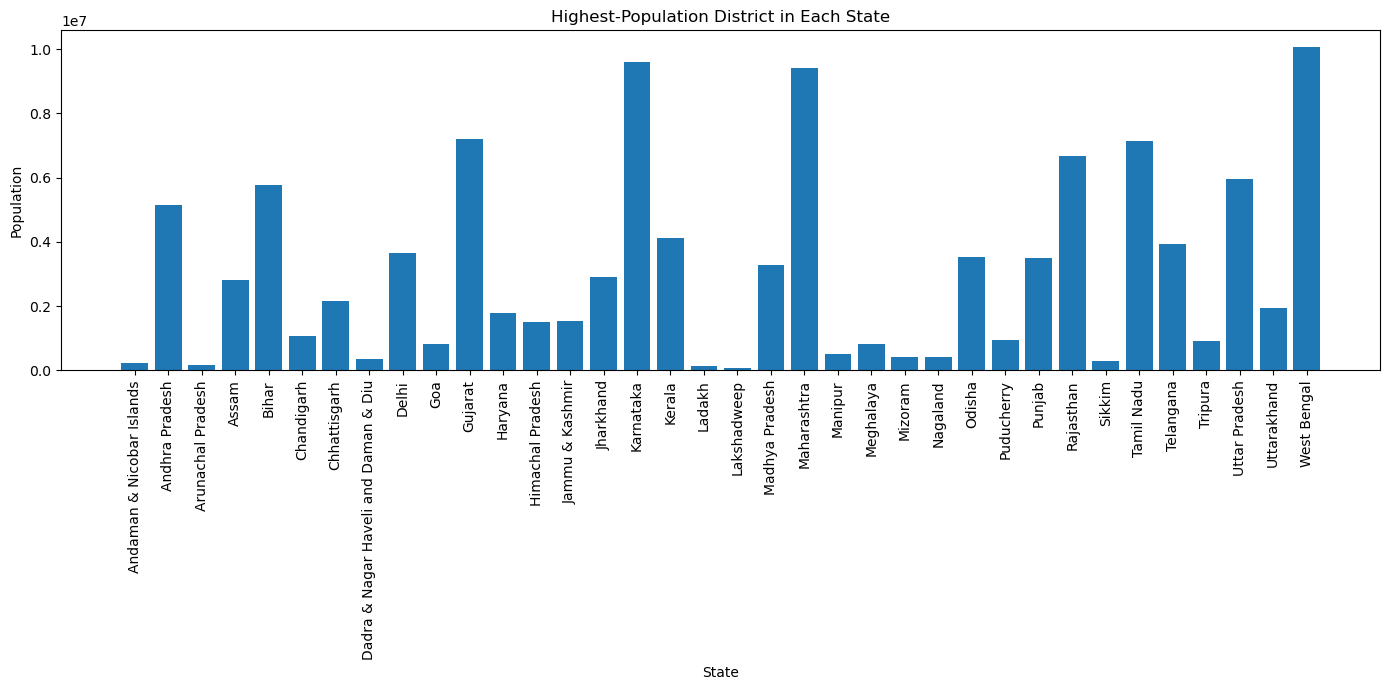

In [10]:
# 2.4 District with highest population for each state
idx = district_demo.groupby('State')['Population'].idxmax()
top_population_district = district_demo.loc[
    idx, ['State','District','Population']
].sort_values('State')
display(top_population_district)

plt.figure(figsize=(14,7))
plt.bar(top_population_district['State'], top_population_district['Population'])
plt.xticks(rotation=90)
plt.title('Highest-Population District in Each State')
plt.xlabel('State')
plt.ylabel('Population')
plt.tight_layout()
plt.show()


In [11]:
# 2.5 Average ATV by state
# Weighted ATV is more appropriate when transaction counts are available.
atv_by_state = state_txn.groupby('State').apply(
    lambda x: x['Amount (INR)'].sum() / x['Transactions'].sum()
).rename('ATV').sort_values(ascending=False)

display(atv_by_state.to_frame())

print('Top 5 states by ATV')
display(atv_by_state.head(5).to_frame())

print('Bottom 5 states by ATV')
display(atv_by_state.tail(5).sort_values().to_frame())


C:\Users\SHRUTI\AppData\Local\Temp\ipykernel_15808\3986938309.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  atv_by_state = state_txn.groupby('State').apply(


,ATV
State,
Ladakh,"3,514.15"
Andaman & Nicobar Islands,"2,976.40"
Mizoram,"2,920.85"
Manipur,"2,905.76"
Nagaland,"2,794.14"
Arunachal Pradesh,"2,766.33"
Lakshadweep,"2,683.41"
Jammu & Kashmir,"2,430.35"
Bihar,"2,297.47"


Top 5 states by ATV


,ATV
State,
Ladakh,"3,514.15"
Andaman & Nicobar Islands,"2,976.40"
Mizoram,"2,920.85"
Manipur,"2,905.76"
Nagaland,"2,794.14"


Bottom 5 states by ATV


,ATV
State,
Karnataka,"1,463.04"
Dadra & Nagar Haveli and Daman & Diu,"1,497.23"
Maharashtra,"1,514.29"
West Bengal,"1,541.68"
Delhi,"1,631.94"


,State,Year,Quarter,App Opens
0,Andaman & Nicobar Islands,2018,1,0
1,Andaman & Nicobar Islands,2018,2,0
2,Andaman & Nicobar Islands,2018,3,0
3,Andaman & Nicobar Islands,2018,4,0
4,Andaman & Nicobar Islands,2019,1,0
...,...,...,...,...
499,West Bengal,2020,2,198589332
500,West Bengal,2020,3,246554831
501,West Bengal,2020,4,291721919
502,West Bengal,2021,1,316832674


,Year,Quarter,App Opens,Period
0,2018,1,0,2018-Q1
1,2018,2,0,2018-Q2
2,2018,3,0,2018-Q3
3,2018,4,0,2018-Q4
4,2019,1,0,2019-Q1
5,2019,2,920409531,2019-Q2
6,2019,3,3448355858,2019-Q3
7,2019,4,4301061532,2019-Q4
8,2020,1,4768934587,2020-Q1
9,2020,2,4357622260,2020-Q2


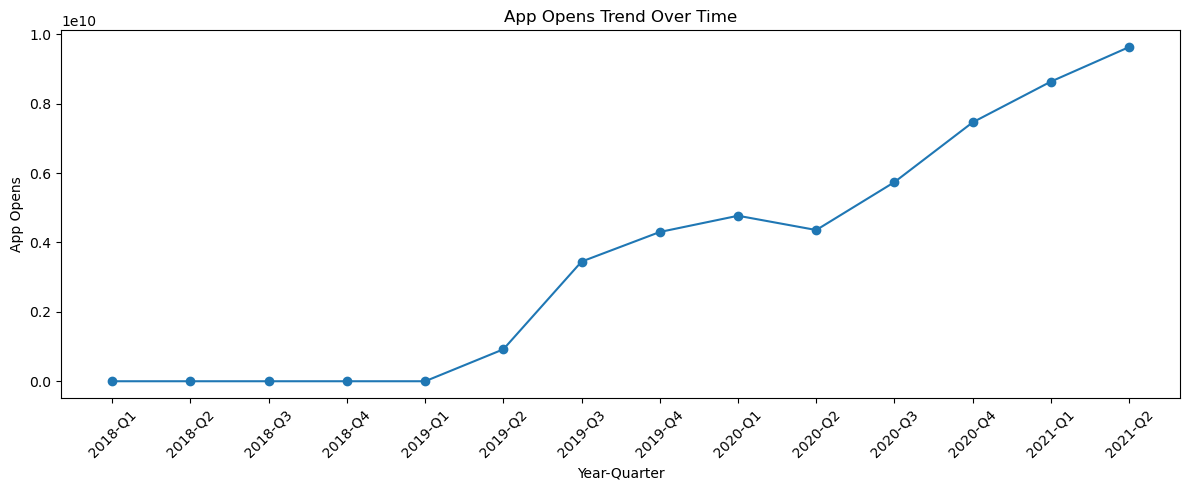

In [12]:
# 2.6 App usage trends
app_usage = state_txn.groupby(['State','Year','Quarter'], as_index=False)['App Opens'].sum()
display(app_usage)

# Overall quarterly trend
quarterly_app_usage = state_txn.groupby(['Year','Quarter'], as_index=False)['App Opens'].sum()
quarterly_app_usage['Period'] = (
    quarterly_app_usage['Year'].astype(str) + '-Q' +
    quarterly_app_usage['Quarter'].astype(str)
)
display(quarterly_app_usage)

plt.figure(figsize=(12,5))
plt.plot(quarterly_app_usage['Period'], quarterly_app_usage['App Opens'], marker='o')
plt.xticks(rotation=45)
plt.title('App Opens Trend Over Time')
plt.xlabel('Year-Quarter')
plt.ylabel('App Opens')
plt.tight_layout()
plt.show()


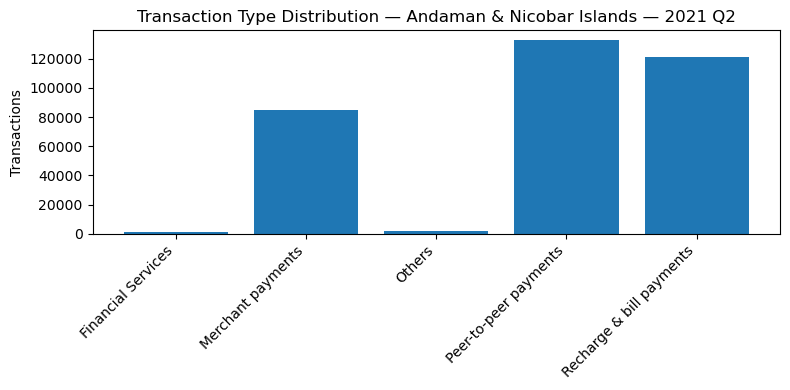

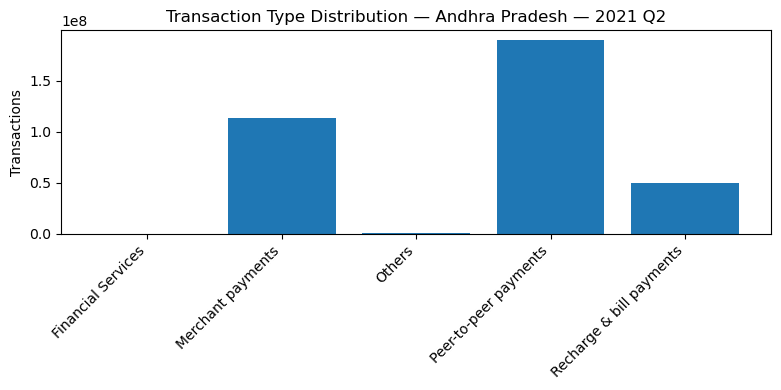

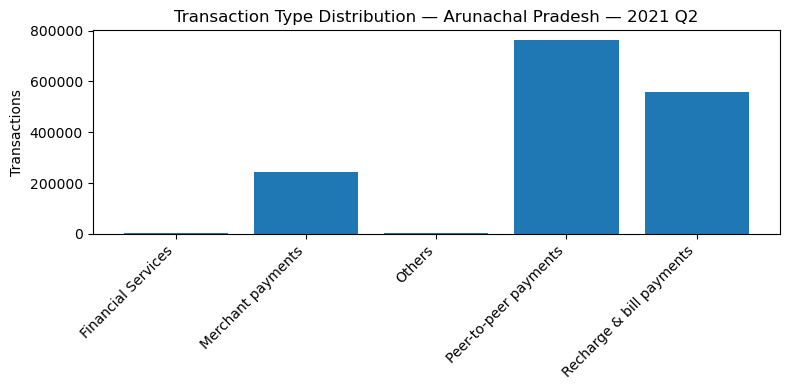

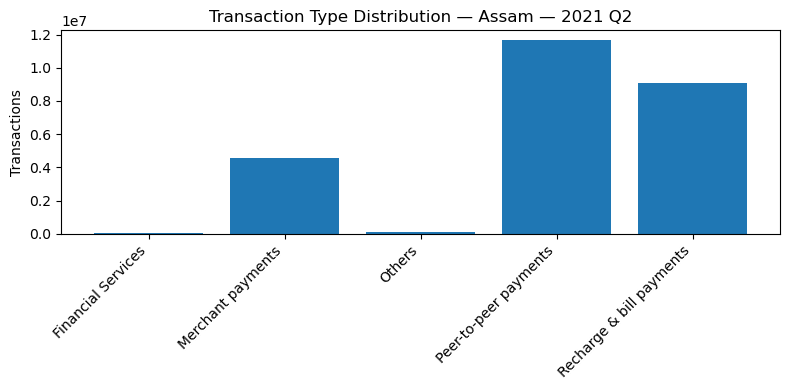

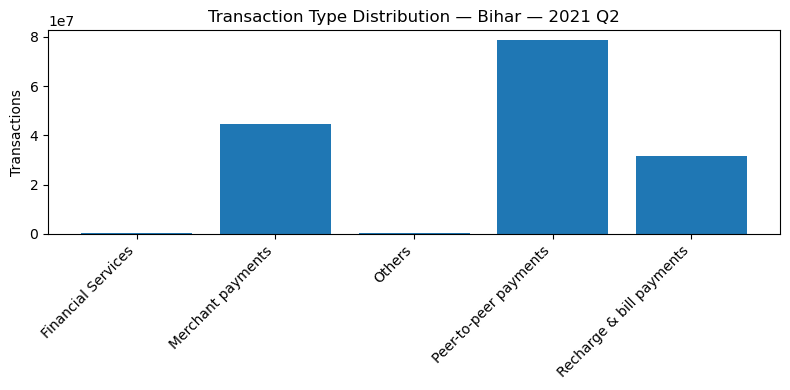

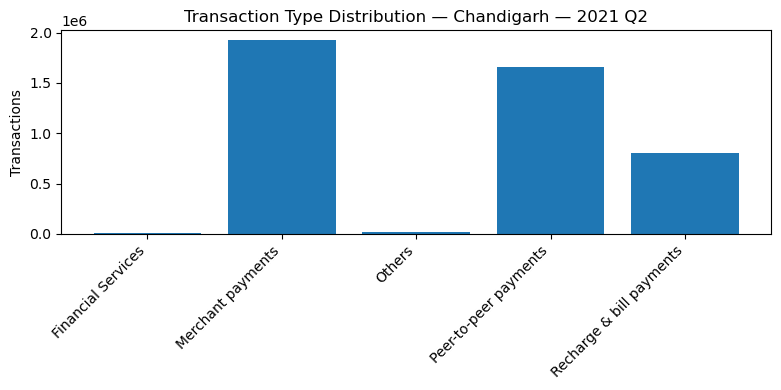

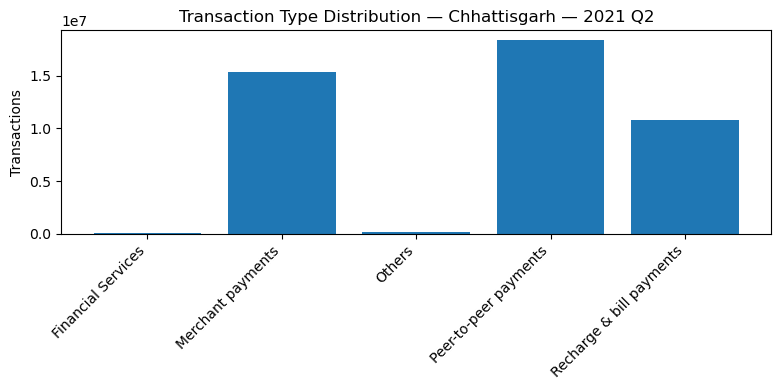

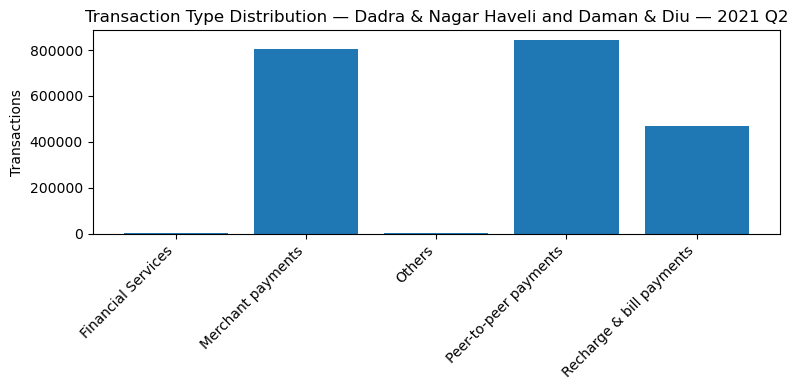

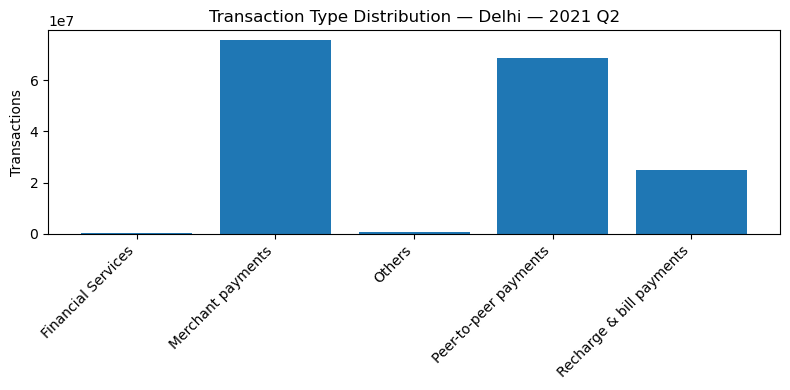

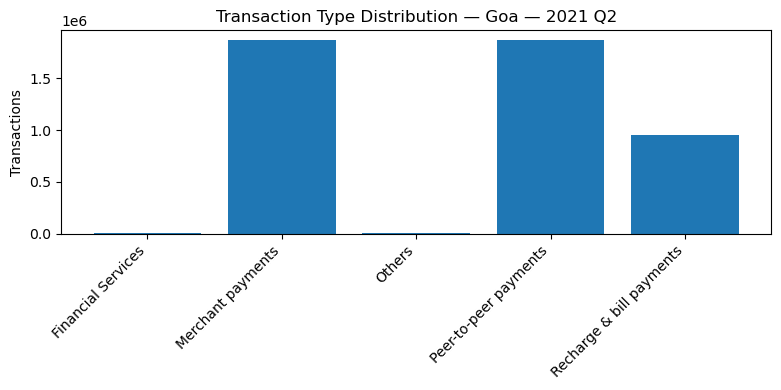

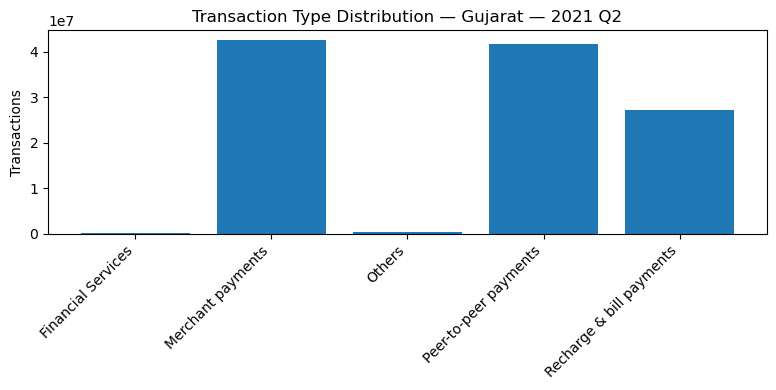

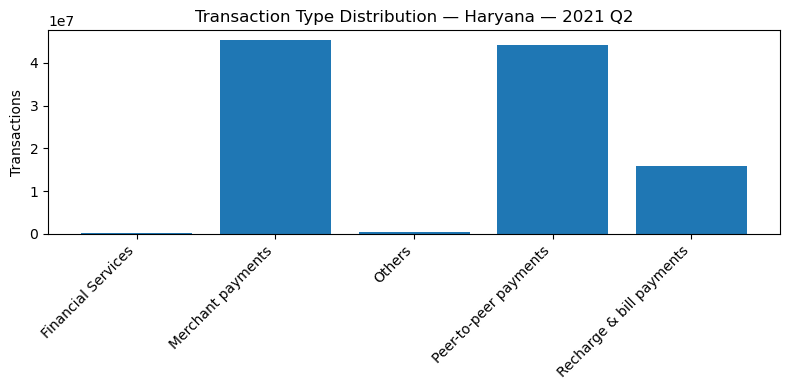

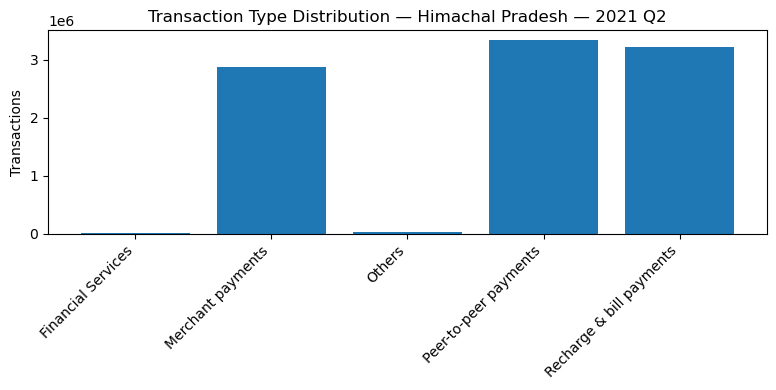

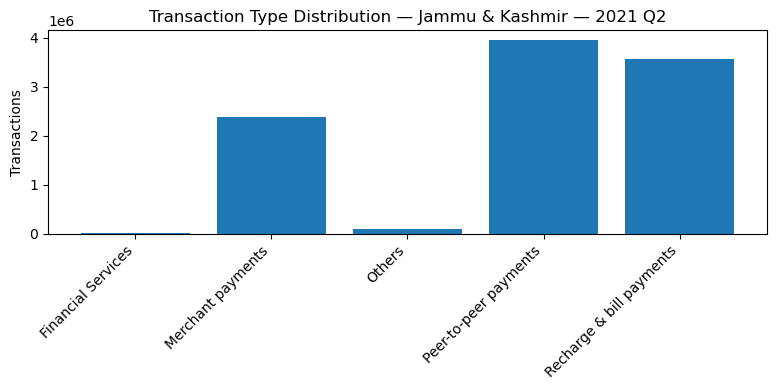

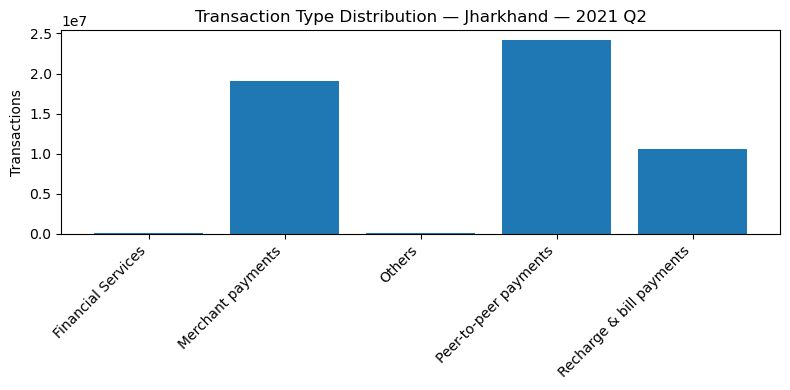

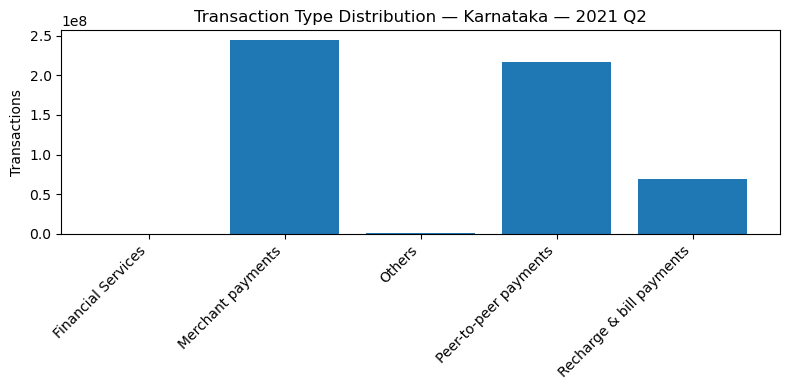

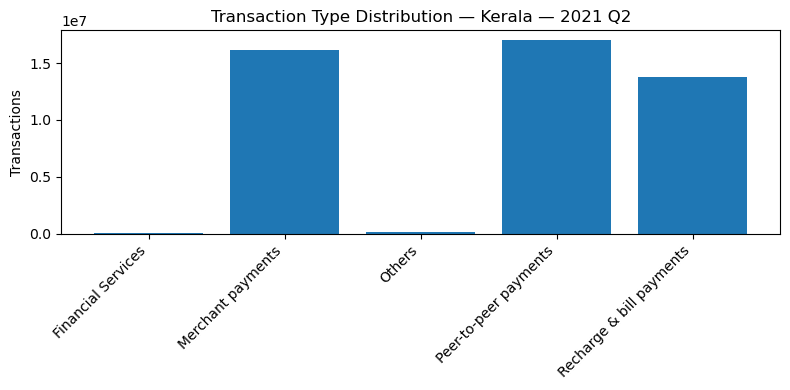

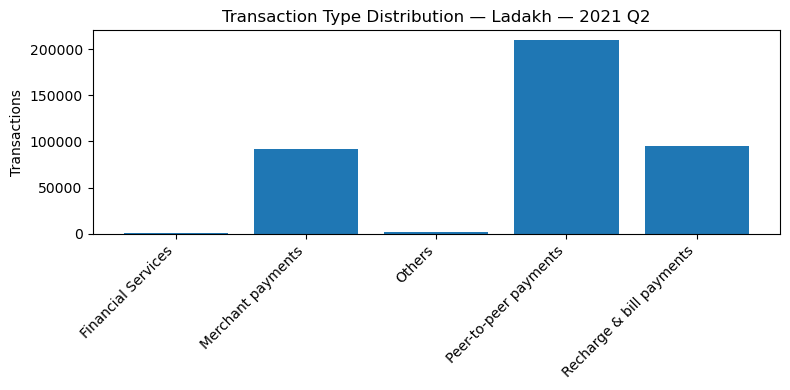

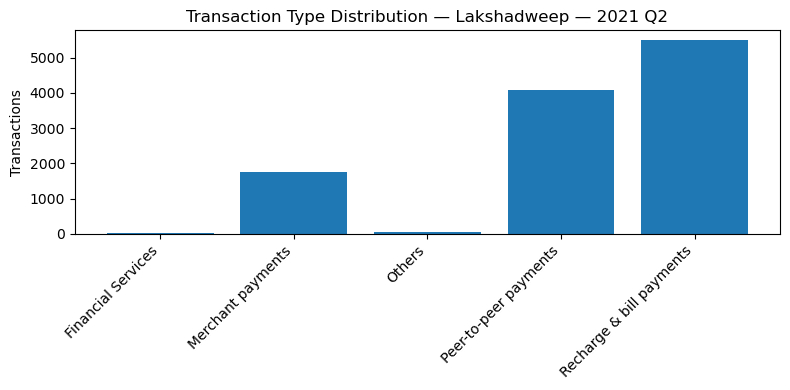

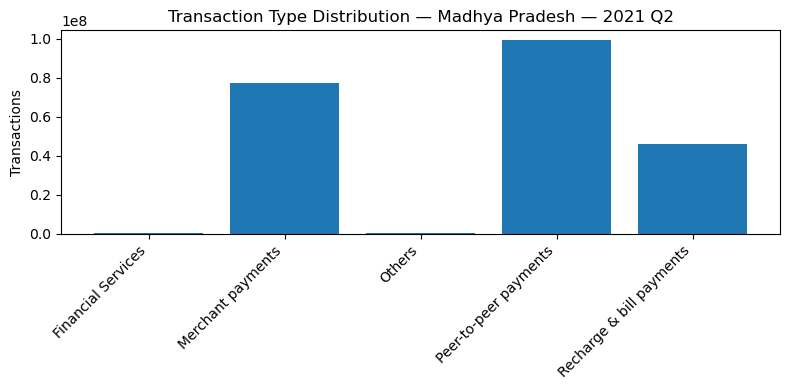

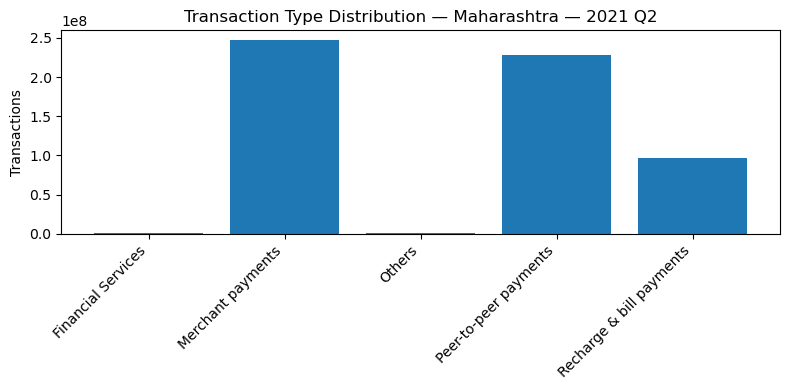

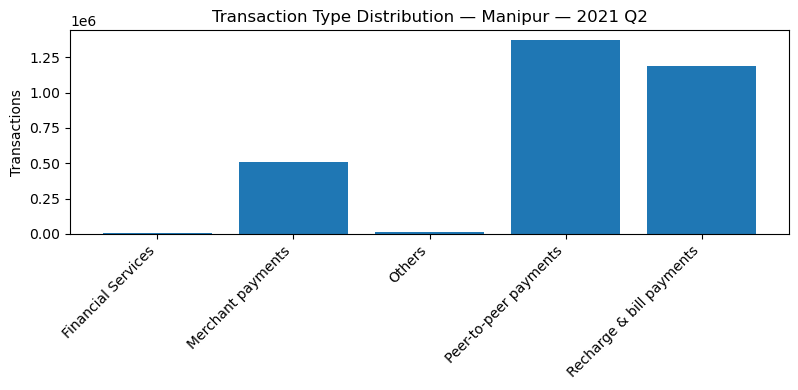

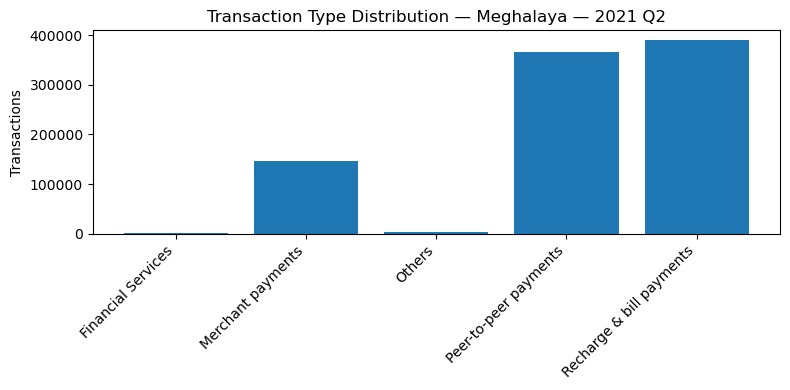

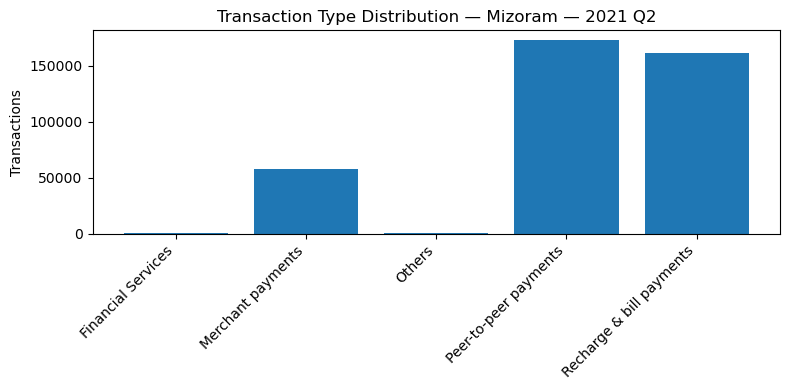

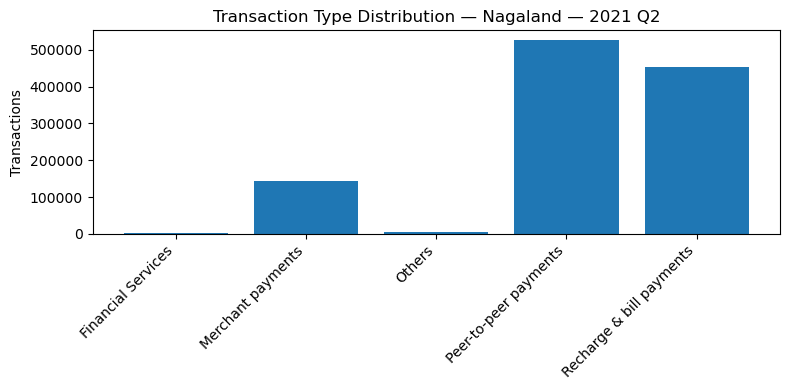

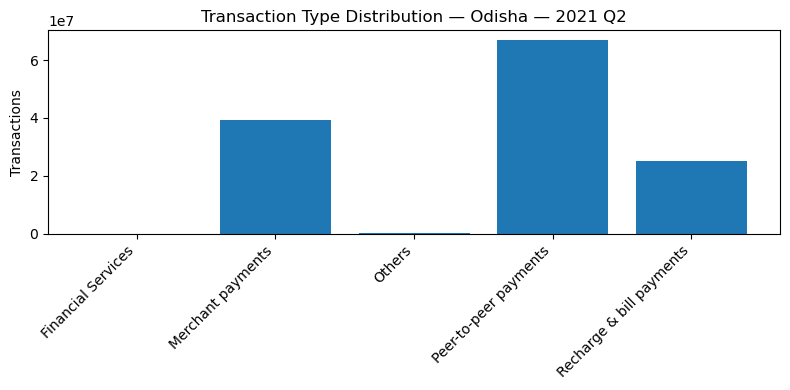

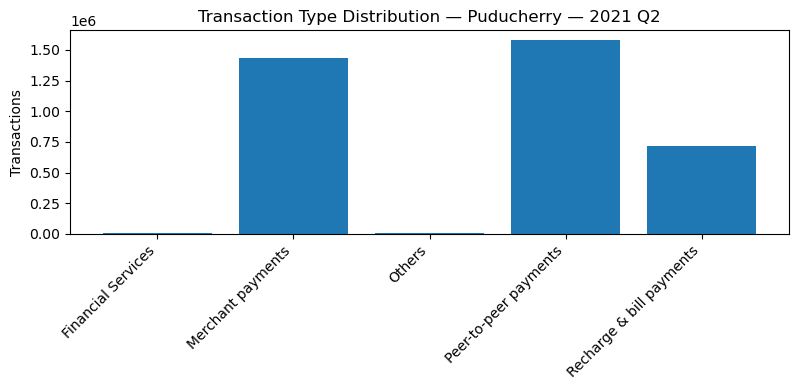

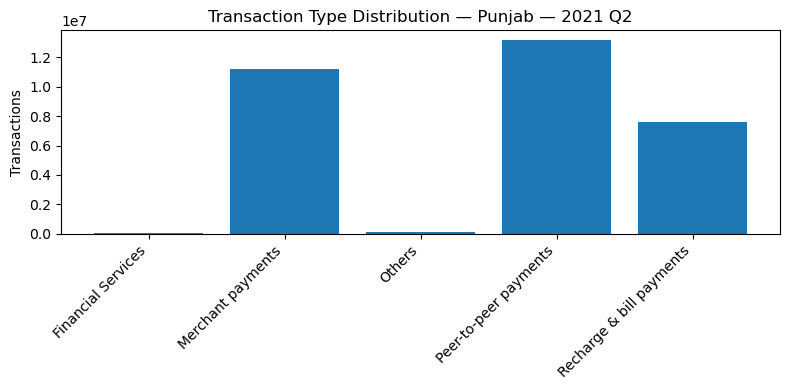

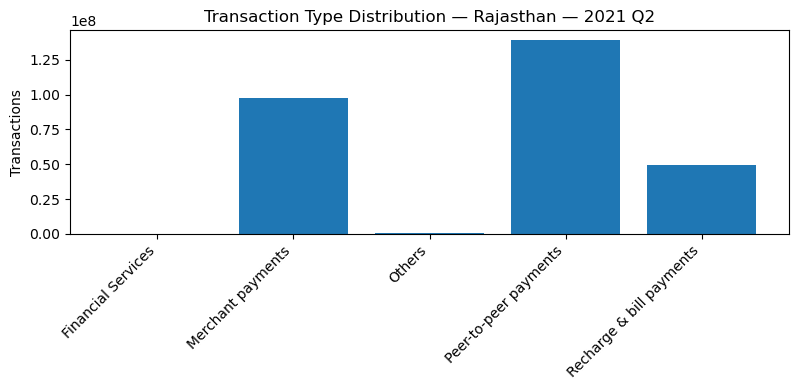

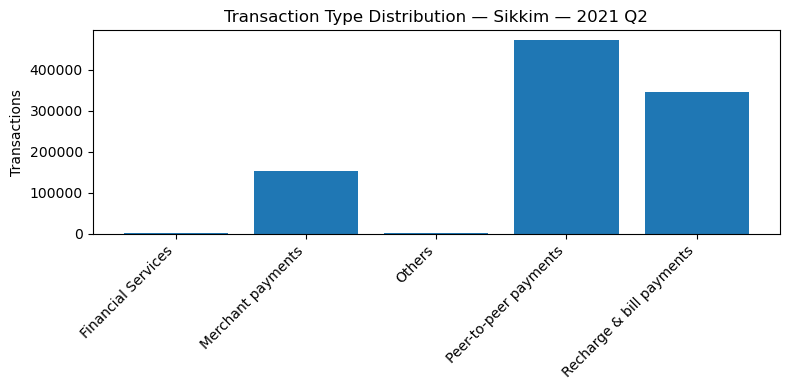

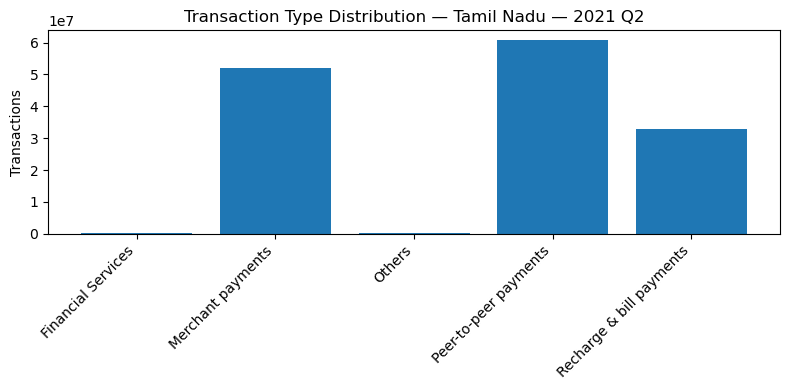

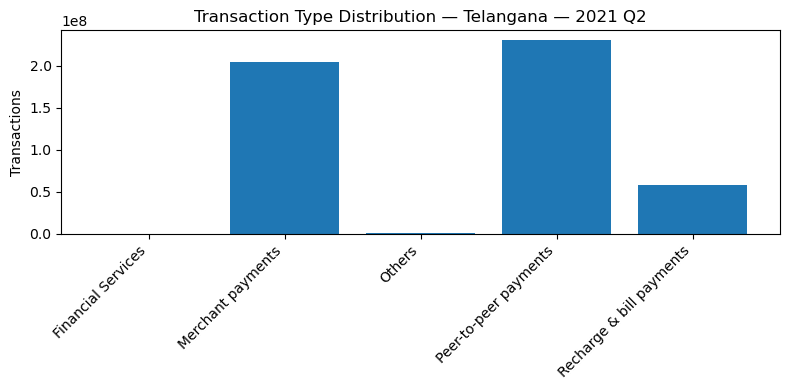

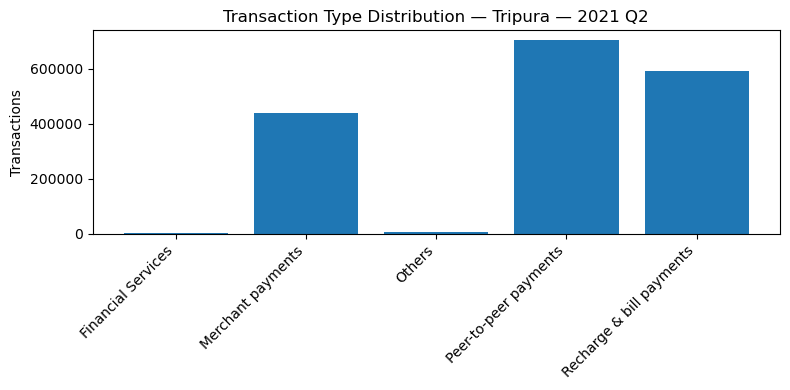

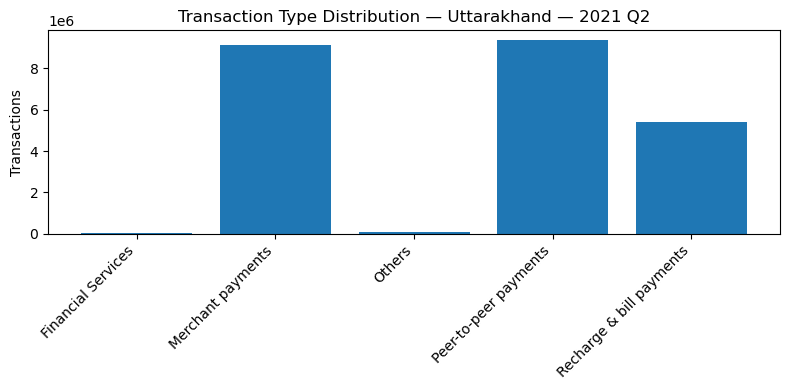

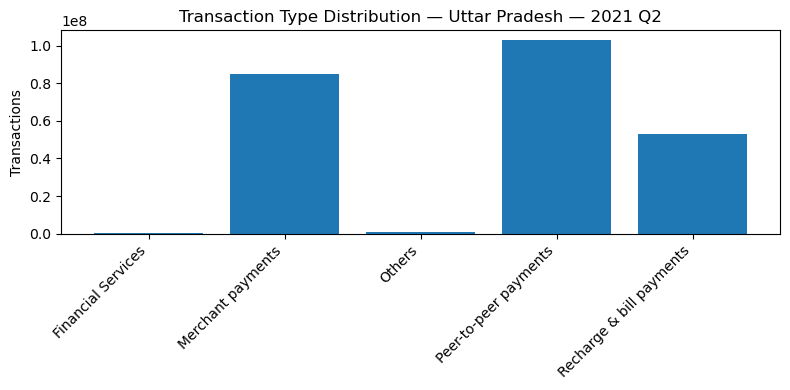

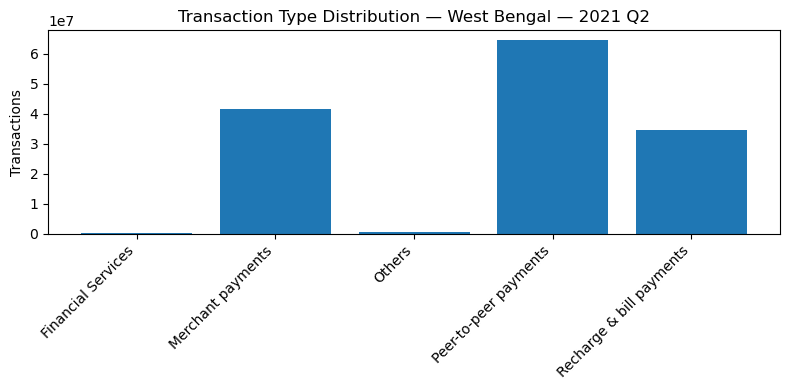

In [13]:
# 2.7 Distribution of transaction types for each state in the latest available quarter
latest_year = state_split['Year'].max()
latest_q = state_split.loc[state_split['Year'].eq(latest_year), 'Quarter'].max()

latest_split = state_split[
    (state_split['Year'] == latest_year) &
    (state_split['Quarter'] == latest_q)
]

for state in latest_split['State'].unique():
    temp = latest_split[latest_split['State'] == state].groupby(
        'Transaction Type', as_index=False
    )['Transactions'].sum()

    plt.figure(figsize=(8,4))
    plt.bar(temp['Transaction Type'], temp['Transactions'])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'Transaction Type Distribution — {state} — {latest_year} Q{latest_q}')
    plt.ylabel('Transactions')
    plt.tight_layout()
    plt.show()


In [14]:
# 2.8 Unique district-name to district-code mapping
district_mapping = district_demo[['District','Code']].drop_duplicates().sort_values('District')

# Validate whether a district maps to more than one code
mapping_check = district_mapping.groupby('District')['Code'].nunique()
ambiguous = mapping_check[mapping_check > 1]

print('Ambiguous district-to-code mappings:', len(ambiguous))
if not ambiguous.empty:
    display(ambiguous)

district_mapping.to_csv('district_name_code_mapping.csv', index=False)
display(district_mapping.head(20))
print('CSV exported as district_name_code_mapping.csv')


Ambiguous district-to-code mappings: 6


District
Aurangabad    2
Balrampur     2
Bijapur       2
Bilaspur      2
Hamirpur      2
Pratapgarh    2
Name: Code, dtype: int64

,District,Code
545,Adilabad,TG01
276,Agar Malwa,MP01
586,Agra,UP01
140,Ahmedabad,GJ01
331,Ahmednagar,MH01
394,Aizawl,MZ01
470,Ajmer,RJ01
332,Akola,MH02
262,Alappuzha,KL01
587,Aligarh,UP02


CSV exported as district_name_code_mapping.csv


## 3. Data Quality Checks

In [15]:
# 3.1 Reconcile district totals with state totals
district_agg = district_txn.groupby(['State','Year','Quarter'], as_index=False).agg(
    District_Transactions=('Transactions','sum'),
    District_Amount=('Amount (INR)','sum')
)

state_agg = state_txn.groupby(['State','Year','Quarter'], as_index=False).agg(
    State_Transactions=('Transactions','sum'),
    State_Amount=('Amount (INR)','sum')
)

reconciliation = state_agg.merge(
    district_agg, on=['State','Year','Quarter'], how='outer', indicator=True
)

reconciliation['Transaction_Difference'] = (
    reconciliation['State_Transactions'] - reconciliation['District_Transactions']
)
reconciliation['Amount_Difference'] = (
    reconciliation['State_Amount'] - reconciliation['District_Amount']
)

discrepancies = reconciliation[
    (reconciliation['Transaction_Difference'].abs() > 1e-6) |
    (reconciliation['Amount_Difference'].abs() > 1e-6)
]

print('Number of state-quarter discrepancies:', len(discrepancies))
display(discrepancies)


Number of state-quarter discrepancies: 389


,State,Year,Quarter,State_Transactions,State_Amount,District_Transactions,District_Amount,_merge,Transaction_Difference,Amount_Difference
14,Andhra Pradesh,2018,1,9039585,"11,996,276,391.82",9039585,"11,996,276,391.82",both,0,0.00
15,Andhra Pradesh,2018,2,12353918,"22,883,914,272.63",12353918,"22,883,914,272.63",both,0,-0.00
16,Andhra Pradesh,2018,3,25626061,"35,718,044,599.21",25626061,"35,718,044,599.21",both,0,0.00
17,Andhra Pradesh,2018,4,30759548,"51,473,779,406.84",30759548,"51,473,779,406.84",both,0,-0.00
18,Andhra Pradesh,2019,1,57264522,"83,760,595,917.08",57264522,"83,760,595,917.08",both,0,-0.00
...,...,...,...,...,...,...,...,...,...,...
499,West Bengal,2020,2,57676797,"100,099,431,877.36",57676797,"100,099,431,877.35",both,0,0.00
500,West Bengal,2020,3,79954504,"156,813,355,855.14",79954504,"156,813,355,855.14",both,0,0.00
501,West Bengal,2020,4,100340645,"199,165,491,365.65",100340645,"199,165,491,365.65",both,0,-0.00
502,West Bengal,2021,1,118254052,"242,937,207,475.52",118254052,"242,937,207,475.52",both,0,-0.00


## 4. Data Merging and Advanced Analysis

,State,Registered Users,Population,User_Population_Ratio
8,Delhi,11182699,16787941,0.67
7,Dadra & Nagar Haveli and Daman & Diu,344994,586956,0.59
31,Telangana,18306880,36366570,0.50
5,Chandigarh,448572,1055450,0.43
15,Karnataka,25751023,60965960,0.42
9,Goa,609106,1457723,0.42
11,Haryana,10530594,25855357,0.41
1,Andhra Pradesh,19620905,49378776,0.40
20,Maharashtra,39664697,112378989,0.35
34,Uttarakhand,3004040,10116752,0.30


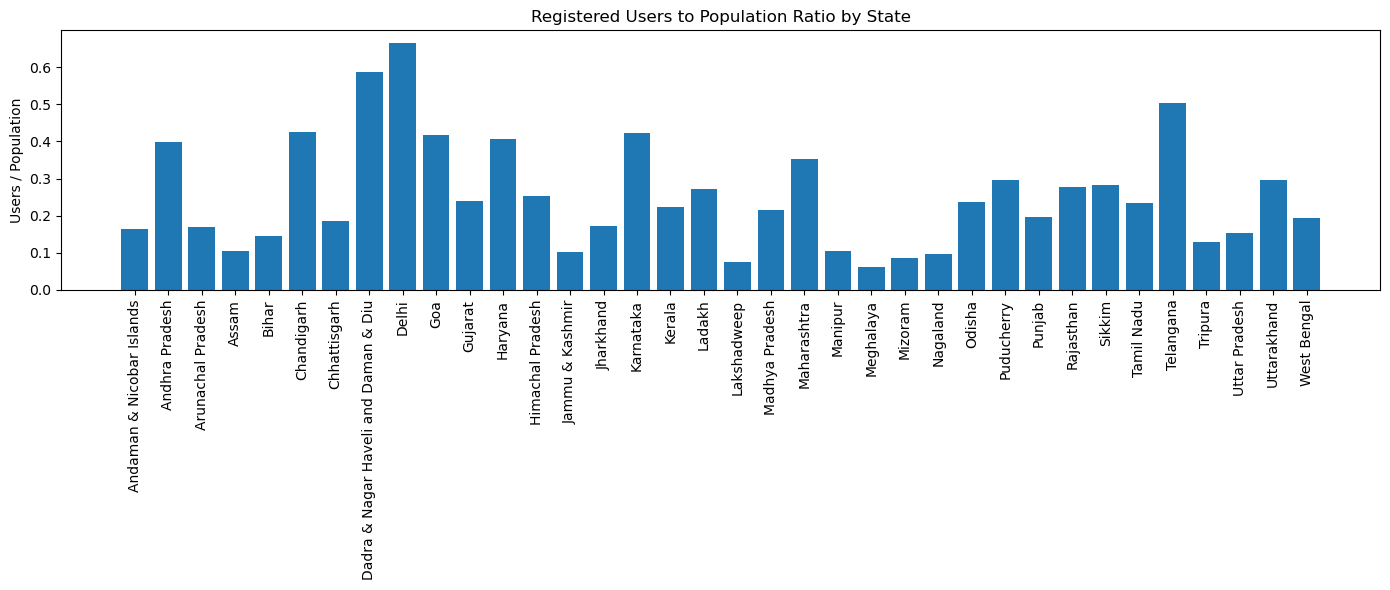

In [16]:
# 4.1 State users-to-population ratio
# Use the state-level user table directly and demographic population aggregated to state.
state_population = district_demo.groupby('State', as_index=False)['Population'].sum()
state_users = state_txn.groupby('State', as_index=False)['Registered Users'].max()

user_population = state_users.merge(state_population, on='State', how='inner')
user_population['User_Population_Ratio'] = (
    user_population['Registered Users'] / user_population['Population']
)
display(user_population.sort_values('User_Population_Ratio', ascending=False))

plt.figure(figsize=(14,6))
plt.bar(user_population['State'], user_population['User_Population_Ratio'])
plt.xticks(rotation=90)
plt.title('Registered Users to Population Ratio by State')
plt.ylabel('Users / Population')
plt.tight_layout()
plt.show()


Pearson correlation: 0.41880419499596916


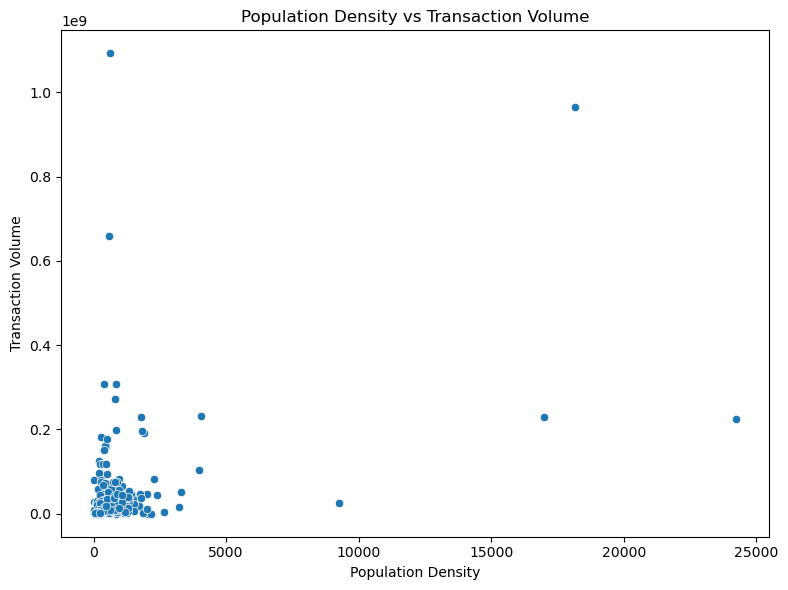

In [17]:
# 4.2 Population density vs transaction volume
# Aggregate district demographics to the district level and transaction data over all periods.
district_txn_total = district_txn.groupby(
    ['State','District','Code'], as_index=False
).agg(Transactions=('Transactions','sum'))

demo_cols = district_demo[['State','District','Code','Density','Population']].drop_duplicates()

density_txn = district_txn_total.merge(
    demo_cols, on=['State','District','Code'], how='inner'
)

correlation = density_txn['Density'].corr(density_txn['Transactions'])
print('Pearson correlation:', correlation)

plt.figure(figsize=(8,6))
sns.scatterplot(data=density_txn, x='Density', y='Transactions')
plt.title('Population Density vs Transaction Volume')
plt.xlabel('Population Density')
plt.ylabel('Transaction Volume')
plt.tight_layout()
plt.show()


In [18]:
# 4.3 Average transaction amount per registered user
state_amount = state_txn.groupby('State', as_index=False)['Amount (INR)'].sum()
state_users = state_txn.groupby('State', as_index=False)['Registered Users'].max()

amount_per_user = state_amount.merge(state_users, on='State', how='inner')
amount_per_user['Avg_Transaction_Amount_Per_User'] = (
    amount_per_user['Amount (INR)'] / amount_per_user['Registered Users']
)

amount_per_user = amount_per_user.sort_values(
    'Avg_Transaction_Amount_Per_User', ascending=False
)

display(amount_per_user)

print('Top 5')
display(amount_per_user.head(5))

print('Bottom 5')
display(amount_per_user.tail(5).sort_values('Avg_Transaction_Amount_Per_User'))


,State,Amount (INR),Registered Users,Avg_Transaction_Amount_Per_User
31,Telangana,"4,574,245,879,737.88",18306880,"249,864.85"
15,Karnataka,"4,361,395,878,908.12",25751023,"169,367.87"
1,Andhra Pradesh,"3,187,847,468,851.51",19620905,"162,471.99"
8,Delhi,"1,649,942,211,116.08",11182699,"147,544.19"
28,Rajasthan,"2,625,584,351,280.98",18980985,"138,327.09"
25,Odisha,"1,220,614,556,987.25",9891029,"123,406.23"
19,Madhya Pradesh,"1,915,100,967,832.55",15940935,"120,137.30"
5,Chandigarh,"53,712,084,630.82",448572,"119,740.16"
4,Bihar,"1,639,578,926,751.51",14972134,"109,508.70"
20,Maharashtra,"4,290,995,253,332.02",39664697,"108,181.72"


Top 5


,State,Amount (INR),Registered Users,Avg_Transaction_Amount_Per_User
31,Telangana,"4,574,245,879,737.88",18306880,"249,864.85"
15,Karnataka,"4,361,395,878,908.12",25751023,"169,367.87"
1,Andhra Pradesh,"3,187,847,468,851.51",19620905,"162,471.99"
8,Delhi,"1,649,942,211,116.08",11182699,"147,544.19"
28,Rajasthan,"2,625,584,351,280.98",18980985,"138,327.09"


Bottom 5


,State,Amount (INR),Registered Users,Avg_Transaction_Amount_Per_User
18,Lakshadweep,"192,158,684.67",4896,"39,248.10"
32,Tripura,"20,970,514,761.53",472153,"44,414.66"
16,Kerala,"372,959,870,819.69",7416083,"50,290.68"
7,Dadra & Nagar Haveli and Daman & Diu,"18,658,784,568.34",344994,"54,084.37"
12,Himachal Pradesh,"97,865,455,329.56",1743151,"56,142.84"


,State,Brand,Registered Users,Total Device Users,Device_Usage_Ratio
11,Andaman & Nicobar Islands,Xiaomi,97889,408396,0.24
10,Andaman & Nicobar Islands,Vivo,88408,408396,0.22
8,Andaman & Nicobar Islands,Samsung,77065,408396,0.19
5,Andaman & Nicobar Islands,Oppo,36007,408396,0.09
6,Andaman & Nicobar Islands,Others,33630,408396,0.08
...,...,...,...,...,...
436,West Bengal,Asus,2775479,144242183,0.02
438,West Bengal,Huawei,2239841,144242183,0.02
440,West Bengal,Micromax,1981032,144242183,0.01
437,West Bengal,Gionee,206751,144242183,0.00


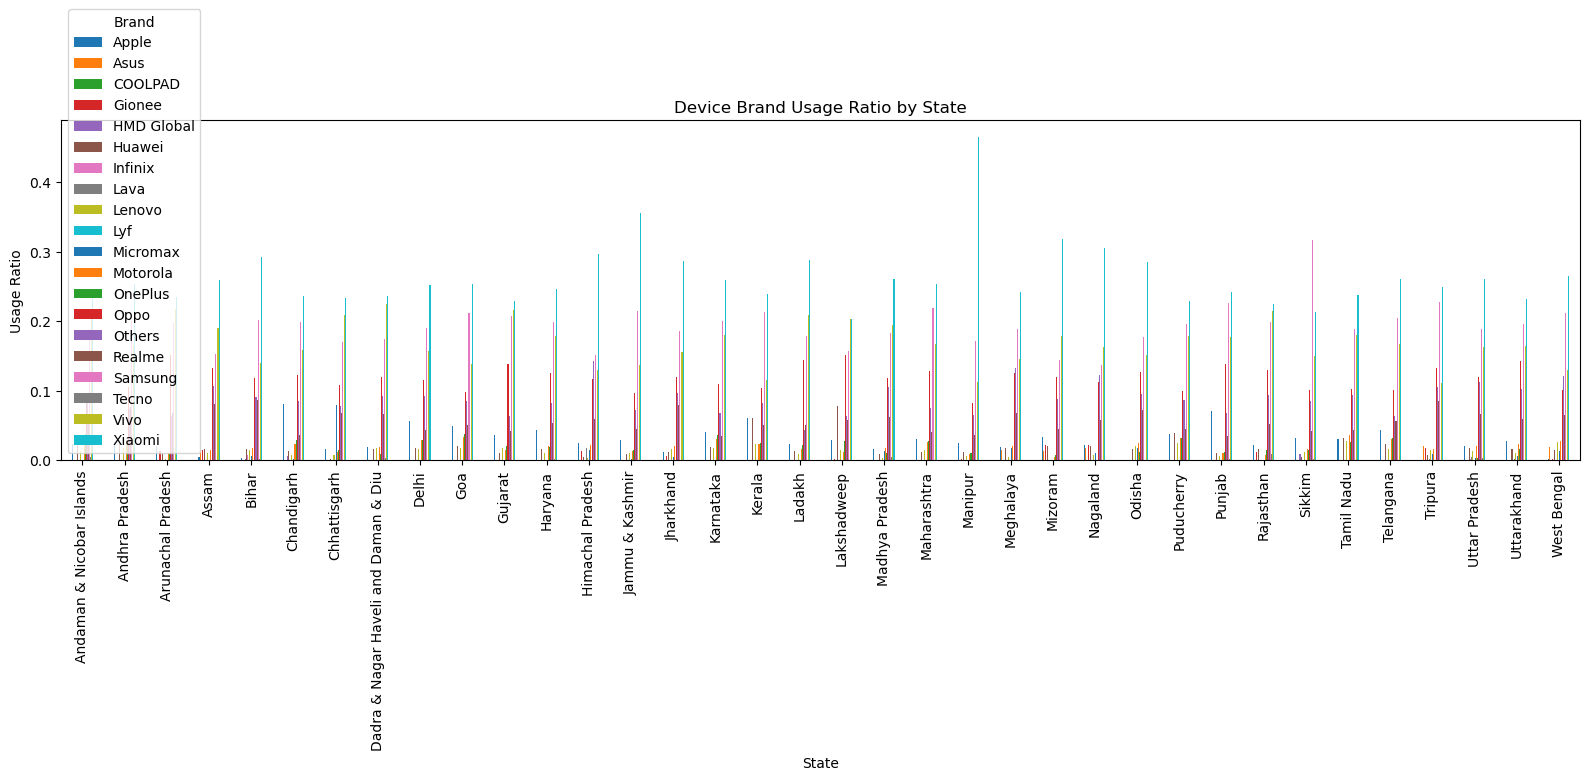

In [19]:
# 4.4 Device brand usage ratio
# Percentage is already the brand share within each state-period.
# Aggregate users across periods, then calculate brand share against total state-period users.
device_users = state_device.groupby(['State','Brand'], as_index=False)['Registered Users'].sum()
device_totals = device_users.groupby('State', as_index=False)['Registered Users'].sum()
device_totals = device_totals.rename(columns={'Registered Users':'Total Device Users'})

device_ratio = device_users.merge(device_totals, on='State', how='left')
device_ratio['Device_Usage_Ratio'] = (
    device_ratio['Registered Users'] / device_ratio['Total Device Users']
)

display(device_ratio.sort_values(['State','Device_Usage_Ratio'], ascending=[True,False]))

# Plot top brands by state
pivot = device_ratio.pivot(index='State', columns='Brand', values='Device_Usage_Ratio')
pivot.plot(kind='bar', figsize=(16,7))
plt.title('Device Brand Usage Ratio by State')
plt.ylabel('Usage Ratio')
plt.xlabel('State')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


## 5. Data Visualization

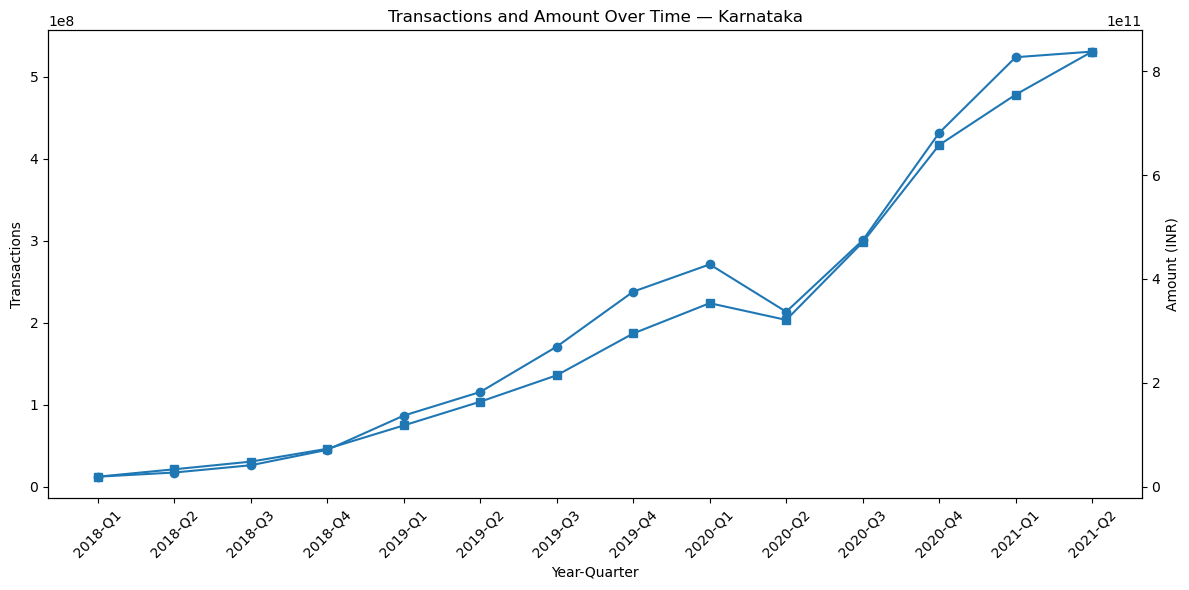

In [20]:
# 5.1 Transactions and amount over time for the state with maximum transaction volume
selected_state = state_txn.groupby('State')['Transactions'].sum().idxmax()
selected = state_txn[state_txn['State'] == selected_state].copy()
selected['Period'] = selected['Year'].astype(str) + '-Q' + selected['Quarter'].astype(str)

selected = selected.sort_values(['Year','Quarter'])

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(selected['Period'], selected['Transactions'], marker='o', label='Transactions')
ax1.set_ylabel('Transactions')
ax1.set_xlabel('Year-Quarter')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.plot(selected['Period'], selected['Amount (INR)'], marker='s', label='Amount (INR)')
ax2.set_ylabel('Amount (INR)')

plt.title(f'Transactions and Amount Over Time — {selected_state}')
plt.tight_layout()
plt.show()


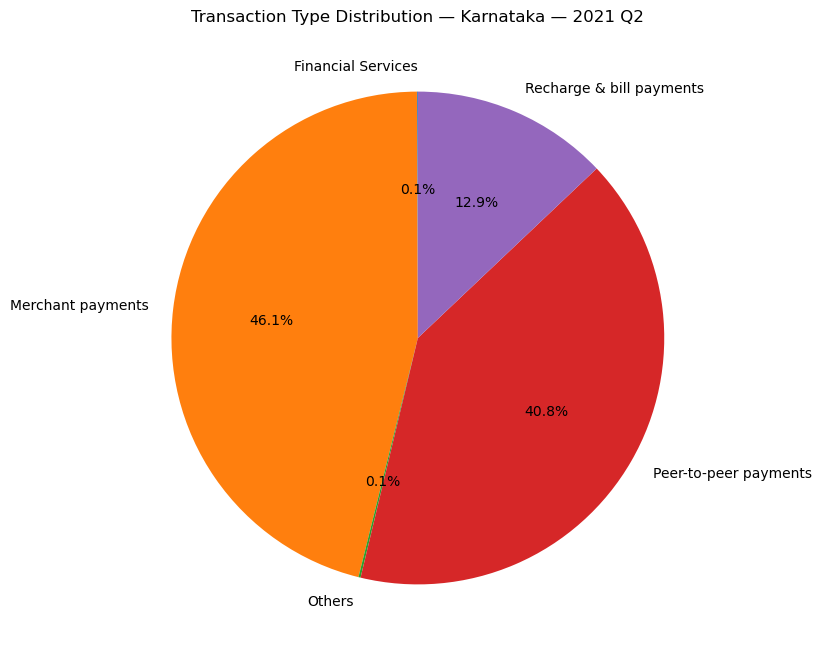

In [21]:
# 5.2 Pie chart for the latest available quarter and highest-transaction state
selected_state = state_txn.groupby('State')['Transactions'].sum().idxmax()
latest_year = state_split['Year'].max()
latest_q = state_split.loc[state_split['Year'].eq(latest_year), 'Quarter'].max()

pie_data = state_split[
    (state_split['State'] == selected_state) &
    (state_split['Year'] == latest_year) &
    (state_split['Quarter'] == latest_q)
].groupby('Transaction Type')['Transactions'].sum()

plt.figure(figsize=(8,8))
plt.pie(pie_data, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
plt.title(f'Transaction Type Distribution — {selected_state} — {latest_year} Q{latest_q}')
plt.show()


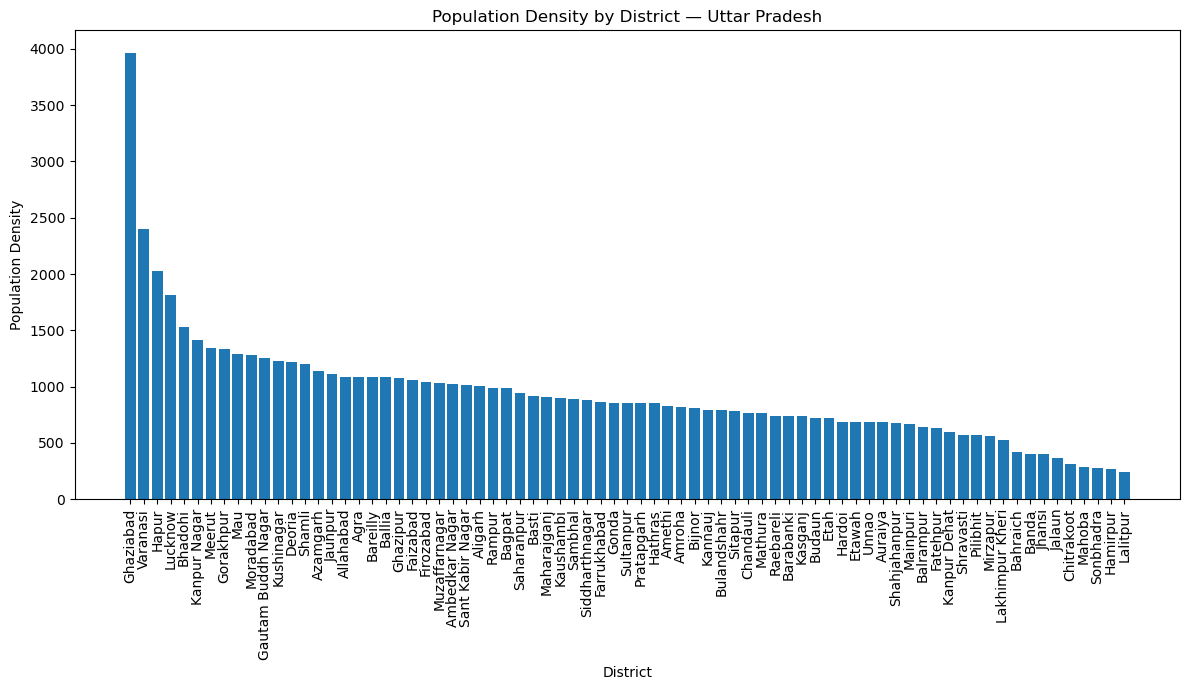

In [22]:
# 5.3 Population density of districts in a selected state
selected_state = district_demo['State'].value_counts().idxmax()
density_selected = district_demo[district_demo['State'] == selected_state].sort_values(
    'Density', ascending=False
)

plt.figure(figsize=(12,7))
plt.bar(density_selected['District'], density_selected['Density'])
plt.xticks(rotation=90)
plt.title(f'Population Density by District — {selected_state}')
plt.xlabel('District')
plt.ylabel('Population Density')
plt.tight_layout()
plt.show()


## 6. Insights and Conclusions

In [23]:
# 6.1 Identify transaction trends
yearly_transactions = state_txn.groupby('Year')['Transactions'].sum()
yearly_amount = state_txn.groupby('Year')['Amount (INR)'].sum()

print('Yearly transaction volume:')
display(yearly_transactions.to_frame())

print('Yearly transaction amount:')
display(yearly_amount.to_frame())

growth = yearly_transactions.pct_change() * 100
print('Year-over-year transaction growth (%):')
display(growth.to_frame('YoY Growth %'))


Yearly transaction volume:


,Transactions
Year,
2018,1080202410
2019,4079827215
2020,7973974741
2021,7398955928


Yearly transaction amount:


,Amount (INR)
Year,
2018,"1,623,045,396,413.89"
2019,"6,276,688,133,188.92"
2020,"14,641,161,978,060.85"
2021,"13,088,264,754,935.71"


Year-over-year transaction growth (%):


,YoY Growth %
Year,
2018,NaN
2019,277.69
2020,95.45
2021,-7.21


In [24]:
# 6.2 Correlate demographic and transaction data
print(f'Correlation between population density and transaction volume: {correlation:.4f}')

if correlation > 0.7:
    interpretation = 'Strong positive relationship'
elif correlation > 0.3:
    interpretation = 'Moderate positive relationship'
elif correlation > -0.3:
    interpretation = 'Weak or negligible linear relationship'
elif correlation > -0.7:
    interpretation = 'Moderate negative relationship'
else:
    interpretation = 'Strong negative relationship'

print('Interpretation:', interpretation)


Correlation between population density and transaction volume: 0.4188
Interpretation: Moderate positive relationship


In [25]:
# 6.3 Key findings and actionable recommendations
top_state = state_txn.groupby('State')['Transactions'].sum().idxmax()
top_state_volume = state_txn.groupby('State')['Transactions'].sum().max()
top_atv_state = atv_by_state.idxmax()
top_atv = atv_by_state.max()
top_density_corr = correlation

findings = [
    f'{top_state} has the highest total transaction volume in the available state-level data ({top_state_volume:,.0f} transactions).',
    f'{top_atv_state} has the highest weighted average transaction value (ATV) among states ({top_atv:,.2f} INR).',
    f'The Pearson correlation between district population density and transaction volume is {top_density_corr:.4f}.',
    'Transaction and app-open trends should be monitored together to identify changes in engagement and monetization.',
    'District-to-state reconciliation should be performed regularly to identify data-quality gaps before reporting.'
]

recommendations = [
    'Prioritize high-volume states for campaigns, merchant expansion and customer-retention initiatives.',
    'Investigate high-ATV states for product categories or customer behaviors that can be replicated elsewhere.',
    'Use district-level density and transaction patterns to prioritize digital-payment infrastructure and localized campaigns.',
    'Monitor app opens alongside transactions to detect engagement changes before they affect transaction volume.',
    'Automate reconciliation checks between state and district datasets in future reporting pipelines.'
]

print('KEY FINDINGS')
for i, item in enumerate(findings, 1):
    print(f'{i}. {item}')

print('\nRECOMMENDATIONS')
for i, item in enumerate(recommendations, 1):
    print(f'{i}. {item}')


KEY FINDINGS
1. Karnataka has the highest total transaction volume in the available state-level data (2,981,044,533 transactions).
2. Ladakh has the highest weighted average transaction value (ATV) among states (3,514.15 INR).
3. The Pearson correlation between district population density and transaction volume is 0.4188.
4. Transaction and app-open trends should be monitored together to identify changes in engagement and monetization.
5. District-to-state reconciliation should be performed regularly to identify data-quality gaps before reporting.

RECOMMENDATIONS
1. Prioritize high-volume states for campaigns, merchant expansion and customer-retention initiatives.
2. Investigate high-ATV states for product categories or customer behaviors that can be replicated elsewhere.
3. Use district-level density and transaction patterns to prioritize digital-payment infrastructure and localized campaigns.
4. Monitor app opens alongside transactions to detect engagement changes before they affect